# Better.com Trustpilot Review Analysis: Keyword Analysis and Topic Modeling

This notebook analyzes the cleaned Better.com Trustpilot review dataset.

**Research focus:** customer experience themes before and after the full implementation of Betsy on **October 17, 2024**.

The notebook is designed to avoid issues encountered in earlier drafts:

- stopwords contaminating topic labels;
- overly loose keyword matching;
- CEO/Zoom-firing outliers distorting topic modeling;
- BERTopic topic collapse into one massive topic;
- `max_df` / `min_df` vectorizer errors;
- overinterpreting direct AI mentions when customers may not explicitly mention AI.

The core analytical logic is:

1. Use **keyword analysis** for hypothesis-driven measurement.
2. Use **BERTopic** for exploratory theme discovery.
3. Interpret all pre/post Betsy patterns cautiously because this is observational review data, not causal evidence.

## 1. Install Required Packages

Run this cell once. If you are using a conda/Jupyter environment and installation seems successful but imports still fail, restart the kernel and rerun the notebook from the top.

In [1]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib plotly scikit-learn wordcloud bertopic sentence-transformers umap-learn hdbscan nbformat kaleido


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

# If Plotly does not render inline, uncomment the next line:
# pio.renderers.default = "browser"

In [3]:
# ── Figure export utility ───────────────────────────────────────────────────
import os as _os

# Robust root detection (redefined in case this cell is run independently)
try:
    _PROJECT_ROOT = PROJECT_ROOT
except NameError:
    from pathlib import Path as _Path
    _PROJECT_ROOT = _Path.cwd()
    if not (_PROJECT_ROOT / "outputs").exists():
        for _parent in _PROJECT_ROOT.parents:
            if (_parent / "outputs").exists():
                _PROJECT_ROOT = _parent
                break

_FIG_DIR = str(_PROJECT_ROOT / "outputs" / "figures" / "NLP")
_os.makedirs(_FIG_DIR, exist_ok=True)

def _save_fig(fig, name, width=1400, height=700):
    """Save Plotly figure as PNG (kaleido) and interactive HTML."""
    _html = _os.path.join(_FIG_DIR, name + '.html')
    _png  = _os.path.join(_FIG_DIR, name + '.png')
    fig.write_html(_html, include_plotlyjs='cdn')
    try:
        fig.write_image(_png, width=width, height=height, scale=2)
        print(f'  Saved PNG : {_os.path.basename(_png)}')
    except Exception as _e:
        print(f'  PNG skipped ({type(_e).__name__}): {_e}')
    print(f'  Saved HTML: {_os.path.basename(_html)}')

print(f'Figure directory ready: {_FIG_DIR}')

Figure directory ready: C:\Users\User\OneDrive\Рабочий стол\Thesis\outputs\figures\NLP


## 3. Load Cleaned Dataset

Expected input file: `better_trustpilot_clean.csv`

The cleaned dataset should contain at least:

- `review_date`
- `review_text`
- `rating`
- optionally `post_betsy`, `period`, `month`

In [4]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "outputs").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "outputs").exists():
            PROJECT_ROOT = parent
            break

DATA_PATH = str(PROJECT_ROOT / "Data" / "NLP" / "better_trustpilot_clean.csv")

df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1', sep=';')

print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head()

Rows: 1915
Columns: ['review_id', 'review_date', 'review_text', 'rating', 'country', 'language', 'verified', 'review_length', 'year', 'month', 'post_betsy', 'period', 'sentiment']


,review_id,review_date,review_text,rating,country,language,verified,review_length,year,month,post_betsy,period,sentiment
0,69ec1710f8734dbf2d13d1aa,4/25/2026 3:21,The whole team was exceptionally helpful and w...,5,US,en,True,170,2026,4/1/2026,1,Post-Betsy,"0,4754"
1,69eacc45947a9857d233c5a3,4/24/2026 3:49,Loan originator and loan coordinator made the ...,5,US,en,True,148,2026,4/1/2026,1,Post-Betsy,"0,8399"
2,69eac948895e1864359c1b0e,4/24/2026 3:37,John and Sonia made my experience outstanding....,5,US,en,True,235,2026,4/1/2026,1,Post-Betsy,"0,7269"
3,69e800cc2103495ba71fbf80,4/22/2026 0:57,"Irene Lee (my loan officer) was professional, ...",5,US,en,True,273,2026,4/1/2026,1,Post-Betsy,"0,9106"
4,69e7539c12572682026d8adb,4/21/2026 12:38,Richard came to my nursery today to help with ...,5,GB,en,False,326,2026,4/1/2026,1,Post-Betsy,"0,8614"


## 4. Basic Dataset Validation

This checks whether the dataset has the required columns before analysis continues.

In [5]:
required_cols = {"review_date", "review_text"}
missing = required_cols - set(df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")

if "rating" not in df.columns:
    print("Warning: 'rating' column not found. Rating-based interpretation will not be available.")

print("Dataset validation passed.")

Dataset validation passed.


## 5. Date Processing and Betsy Cutoff

Betsy full implementation is treated as **October 17, 2024**.

This notebook removes timezone metadata if present to avoid the common pandas error:

`Cannot compare tz-naive and tz-aware datetime-like objects`

In [6]:
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")

# Remove timezone if present
try:
    df["review_date"] = df["review_date"].dt.tz_localize(None)
except TypeError:
    pass  # Already timezone-naive

cutoff_date = pd.Timestamp("2024-10-17")

df = df.dropna(subset=["review_date", "review_text"]).copy()

df["post_betsy"] = (df["review_date"] >= cutoff_date).astype(int)
df["period"]     = np.where(df["post_betsy"] == 1, "Post-Betsy", "Pre-Betsy")
# Re-derive month from parsed date (source CSV stores month as a full date string "M/1/YYYY")
df["month"] = df["review_date"].dt.to_period("M").astype(str)
df["year"]  = df["review_date"].dt.year

# ── Sentiment: parse European comma-decimal format ───────────────────────
if "sentiment" in df.columns:
    df["sentiment_score"] = (
        df["sentiment"].astype(str)
        .str.replace(",", ".", regex=False)
        .apply(pd.to_numeric, errors="coerce")
    )
    valid = df["sentiment_score"].notna().sum()
    print(f"Sentiment parsed: {valid} valid scores | "
          f"range {df['sentiment_score'].min():.4f} – {df['sentiment_score'].max():.4f}")
else:
    df["sentiment_score"] = float("nan")
    print("Warning: no sentiment column found.")

df.groupby("period")["review_date"].agg(["min", "max", "count"])


Sentiment parsed: 1915 valid scores | range -0.9844 – 0.9982


,min,max,count
period,,,
Post-Betsy,2024-10-22 17:20:00,2026-04-25 03:21:00,169
Pre-Betsy,2020-08-22 18:30:00,2024-10-15 04:01:00,1746


## 6. Sample Size and Imbalance Check

This is important because the post-Betsy period may have far fewer observations than the pre-Betsy period.

In [7]:
period_counts = df["period"].value_counts().rename_axis("period").reset_index(name="count")
period_counts["share_%"] = period_counts["count"] / period_counts["count"].sum() * 100
period_counts

,period,count,share_%
0,Pre-Betsy,1746,91.174935
1,Post-Betsy,169,8.825065


**Interpretation note:** If the post-Betsy sample is much smaller than the pre-Betsy sample, post-Betsy thematic shifts should be interpreted cautiously.

## 7. Text Cleaning: Base Version

This version is used for keyword matching. It lowercases text and removes punctuation, but does not remove all substantive words.

In [8]:
# Check which text column exists
print(df.columns)

# Use the correct review text column
text_col = "review_text"

# If your dataset uses another name, uncomment one of these:
# text_col = "reviewDescription"
# text_col = "review_text"

print("Using text column:", text_col)
print(df[text_col].head())

Index(['review_id', 'review_date', 'review_text', 'rating', 'country',
       'language', 'verified', 'review_length', 'year', 'month', 'post_betsy',
       'period', 'sentiment', 'sentiment_score'],
      dtype='object')
Using text column: review_text
0    The whole team was exceptionally helpful and w...
1    Loan originator and loan coordinator made the ...
2    John and Sonia made my experience outstanding....
3    Irene Lee (my loan officer) was professional, ...
4    Richard came to my nursery today to help with ...
Name: review_text, dtype: object


In [9]:
import re

def clean_text_raw_func(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text_raw"] = df[text_col].apply(clean_text_raw_func)

df[["review_text", "clean_text_raw"]].head()

,review_text,clean_text_raw
0,The whole team was exceptionally helpful and w...,the whole team was exceptionally helpful and w...
1,Loan originator and loan coordinator made the ...,loan originator and loan coordinator made the ...
2,John and Sonia made my experience outstanding....,john and sonia made my experience outstanding ...
3,"Irene Lee (my loan officer) was professional, ...",irene lee my loan officer was professional kno...
4,Richard came to my nursery today to help with ...,richard came to my nursery today to help with ...


In [10]:
print("Empty clean_text_raw rows:", (df["clean_text_raw"].str.len() == 0).sum())
print("Missing clean_text_raw rows:", df["clean_text_raw"].isna().sum())

df["clean_text_raw"].head(10)

Empty clean_text_raw rows: 0
Missing clean_text_raw rows: 0


0    the whole team was exceptionally helpful and w...
1    loan originator and loan coordinator made the ...
2    john and sonia made my experience outstanding ...
3    irene lee my loan officer was professional kno...
4    richard came to my nursery today to help with ...
5    better is great helped with a heloc all digita...
6    the process was fast the ppl who helped me was...
7    had a great experience they are very professio...
8    it was very easy the dashboard page kept me up...
9    the whole process was very easy and quick our ...
Name: clean_text_raw, dtype: object

## 8. Text Cleaning: Topic Modeling Version with Stopword Removal

This is the key fix for earlier topic-model outputs that were dominated by words like “the”, “and”, “to”, and “was”.

This version removes:

- standard English stopwords;
- company/domain words that are too common to help topic separation.

In [11]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "better", "mortgage", "loan", "loans", "company",
    "customer", "customers", "experience", "process"
})

def clean_for_topics(text):
    words = str(text).split()
    words = [
        w for w in words
        if w not in custom_stopwords and len(w) > 2
    ]
    return " ".join(words)

df["topic_text"] = df["clean_text_raw"].apply(clean_for_topics)

df[["clean_text_raw", "topic_text"]].head()

,clean_text_raw,topic_text
0,the whole team was exceptionally helpful and w...,team exceptionally helpful able answer questio...
1,loan originator and loan coordinator made the ...,originator coordinator seamless easy navigate ...
2,john and sonia made my experience outstanding ...,john sonia outstanding consummate professional...
3,irene lee my loan officer was professional kno...,irene lee officer professional knowledgeable r...
4,richard came to my nursery today to help with ...,richard came nursery today help phones wifi nu...


In [12]:
print("Empty topic_text rows:", (df["topic_text"].str.len() == 0).sum())
df["topic_text"].head(10)

Empty topic_text rows: 1


0    team exceptionally helpful able answer questio...
1    originator coordinator seamless easy navigate ...
2    john sonia outstanding consummate professional...
3    irene lee officer professional knowledgeable r...
4    richard came nursery today help phones wifi nu...
5    great helped heloc digital signing closing pap...
6                 fast ppl helped professional helpful
7    great professional thorough ability implement ...
8    easy dashboard page kept updated let know info...
9              easy quick officer processor great work
Name: topic_text, dtype: object

## 9. Quick Word Frequency Sanity Check

Use this to verify that stopwords are not dominating the text. If the top words are mostly generic filler words, stopword removal needs further tuning.

In [13]:
from collections import Counter

all_words = " ".join(df["topic_text"].dropna()).split()
word_counts = Counter(all_words)

pd.DataFrame(word_counts.most_common(30), columns=["word", "count"])

,word,count
0,easy,612
1,closing,570
2,great,565
3,time,456
4,team,444
5,recommend,384
6,home,362
7,rate,355
8,questions,348
9,com,343


# Part A — Keyword Analysis

Keyword analysis is hypothesis-driven. It should be kept separate from topic modeling.

Important distinction:

- **Strict AI visibility**: direct mentions of AI/automation.
- **Customer outcome themes**: speed, support, communication, delays, costs.

## 10. Define Keyword Groups

The AI group is intentionally strict. Avoid broad terms like “system”, “online”, or “digital” because those do not necessarily mean AI.

In [14]:
keyword_groups = {
    "Explicit_AI_Automation": [
        "ai", "artificial intelligence", "automation", "automated", "bot", "bots",
        "chatbot", "voice ai", "virtual assistant", "algorithm", "machine learning"
    ],
    "Speed_Efficiency": [
        "fast", "quick", "quickly", "speed", "smooth", "easy", "easier",
        "efficient", "seamless", "timely", "rapid"
    ],
    "Human_Support": [
        "support", "agent", "representative", "loan officer", "coordinator",
        "team", "person", "human", "helpful", "responsive"
    ],
    "Communication": [
        "communication", "communicate", "communicated", "response", "respond",
        "responsive", "email", "call", "phone", "update", "updates"
    ],
    "Delay_Friction": [
        "slow", "delay", "delayed", "waiting", "wait", "frustrating",
        "frustrated", "confusing", "difficult", "issue", "issues", "problem", "problems"
    ],
    "Cost_Rates": [
        "rate", "rates", "fee", "fees", "cost", "costs", "closing cost",
        "price", "expensive", "cheap", "competitive"
    ],
    "Digital_Process": [
        "online", "website", "portal", "app", "application", "upload", "digital", "platform"
    ]
}

## 11. Fixed Keyword Matching with Word Boundaries

This avoids false positives such as matching `ai` inside unrelated words.

In [15]:
def contains_phrase(text, phrase):
    text = str(text).lower()
    phrase = str(phrase).lower()

    # Match full word/phrase, while allowing hyphenated continuations
    pattern = r"\b" + re.escape(phrase) + r"\b"
    return bool(re.search(pattern, text))

def contains_any_phrase(text, phrases):
    return int(any(contains_phrase(text, phrase) for phrase in phrases))

for group, keywords in keyword_groups.items():
    df[group] = df["clean_text_raw"].apply(
        lambda x: contains_any_phrase(x, keywords)
    )

keyword_cols = list(keyword_groups.keys())

df[keyword_cols].head()

,Explicit_AI_Automation,Speed_Efficiency,Human_Support,Communication,Delay_Friction,Cost_Rates,Digital_Process
0,0,1,1,0,0,0,0
1,0,1,1,0,0,1,0
2,0,1,0,0,0,0,0
3,0,0,1,0,0,0,1
4,0,0,0,0,0,0,0


In [16]:
for col in keyword_cols:
    print(col, "matches:", df[col].sum())

Explicit_AI_Automation matches: 22
Speed_Efficiency matches: 983
Human_Support matches: 834
Communication matches: 620
Delay_Friction matches: 253
Cost_Rates matches: 533
Digital_Process matches: 610


## 12. Keyword Summary: Pre vs Post Betsy

In [17]:
keyword_summary = df.groupby("period")[keyword_cols].mean().T * 100
keyword_summary

period,Post-Betsy,Pre-Betsy
Explicit_AI_Automation,1.183432,1.145475
Speed_Efficiency,44.378698,52.004582
Human_Support,40.828402,43.814433
Communication,30.769231,32.531501
Delay_Friction,10.059172,13.516609
Cost_Rates,16.568047,28.923253
Digital_Process,23.668639,32.646048


## 12b. Statistical Significance of Keyword Differences

Use chi-squared tests to determine whether pre/post differences are statistically
significant given the severe class imbalance (Pre-Betsy 91% vs Post-Betsy 9%).
Significance levels: † p<0.10, * p<0.05, ** p<0.01


In [18]:
from scipy.stats import chi2_contingency

chi2_results = []
for col in keyword_cols:
    post = df[df["period"] == "Post-Betsy"][col]
    pre  = df[df["period"] == "Pre-Betsy"][col]

    post_yes, post_no = post.sum(), len(post) - post.sum()
    pre_yes,  pre_no  = pre.sum(),  len(pre)  - pre.sum()

    chi2, p, dof, _ = chi2_contingency([[post_yes, post_no], [pre_yes, pre_no]])

    sig = "**" if p < 0.01 else ("*" if p < 0.05 else ("†" if p < 0.10 else ""))
    chi2_results.append({
        "Keyword Group"  : col,
        "Pre-Betsy %"    : round(pre_yes  / len(pre)  * 100, 2),
        "Post-Betsy %"   : round(post_yes / len(post) * 100, 2),
        "Δ (pp)"          : round(post_yes / len(post) * 100 - pre_yes / len(pre) * 100, 2),
        "χ²"              : round(chi2, 3),
        "p-value"        : round(p, 4),
        "Sig"            : sig
    })

chi2_df = pd.DataFrame(chi2_results)
print(chi2_df.to_string(index=False))
chi2_df


         Keyword Group  Pre-Betsy %  Post-Betsy %  Δ (pp)     χ²  p-value Sig
Explicit_AI_Automation         1.15          1.18    0.04  0.000   1.0000    
      Speed_Efficiency        52.00         44.38   -7.63  3.288   0.0698   †
         Human_Support        43.81         40.83   -2.99  0.444   0.5052    
         Communication        32.53         30.77   -1.76  0.145   0.7029    
        Delay_Friction        13.52         10.06   -3.46  1.319   0.2508    
            Cost_Rates        28.92         16.57  -12.36 11.103   0.0009  **
       Digital_Process        32.65         23.67   -8.98  5.315   0.0211   *


,Keyword Group,Pre-Betsy %,Post-Betsy %,Δ (pp),χ²,p-value,Sig
0,Explicit_AI_Automation,1.15,1.18,0.04,0.000,1.0000,
1,Speed_Efficiency,52.00,44.38,-7.63,3.288,0.0698,†
2,Human_Support,43.81,40.83,-2.99,0.444,0.5052,
3,Communication,32.53,30.77,-1.76,0.145,0.7029,
4,Delay_Friction,13.52,10.06,-3.46,1.319,0.2508,
5,Cost_Rates,28.92,16.57,-12.36,11.103,0.0009,**
6,Digital_Process,32.65,23.67,-8.98,5.315,0.0211,*


## 13. Keyword Summary Visualization

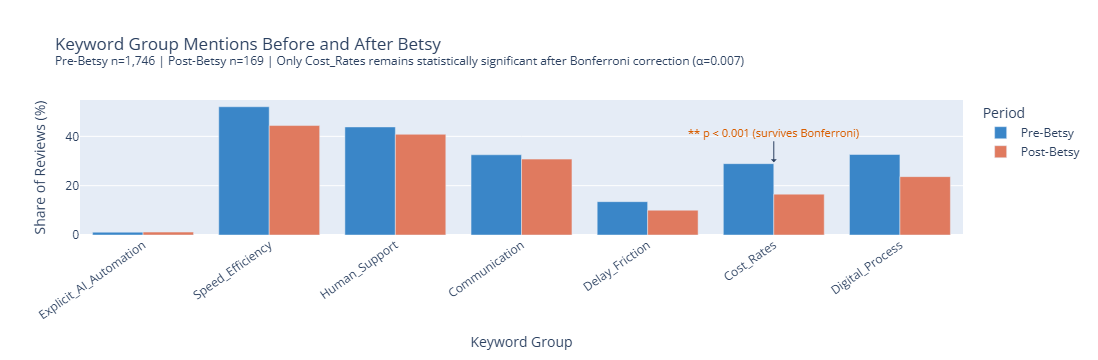

  Saved PNG : fig_nlp_keyword_prevalence_clean.png
  Saved HTML: fig_nlp_keyword_prevalence_clean.html


In [19]:
keyword_summary_long = keyword_summary.reset_index().rename(columns={"index": "keyword_group"})
keyword_summary_long = keyword_summary_long.melt(
    id_vars="keyword_group",
    var_name="period",
    value_name="share_of_reviews_%"
)

n_post = int(df[df["period"] == "Post-Betsy"].shape[0])
n_pre  = int(df[df["period"] == "Pre-Betsy"].shape[0])

fig = px.bar(
    keyword_summary_long,
    x="keyword_group",
    y="share_of_reviews_%",
    color="period",
    barmode="group",
    category_orders={"period": ["Pre-Betsy", "Post-Betsy"]},
    color_discrete_map={"Pre-Betsy": "#3a86c8", "Post-Betsy": "#e07a5f"},
    title="Keyword Group Mentions Before and After Betsy<br>"
          f"<sup>Pre-Betsy n={n_pre:,} | Post-Betsy n={n_post:,} | "
          "Only Cost_Rates remains statistically significant after Bonferroni correction (α=0.007)</sup>",
    labels={"keyword_group": "Keyword Group", "share_of_reviews_%": "Share of Reviews (%)", "period": "Period"}
)

# Significance annotation specifically for Cost_Rates (survives Bonferroni)
fig.add_annotation(
    x="Cost_Rates",
    y=29.5,
    text="** p < 0.001 (survives Bonferroni)",
    showarrow=True,
    arrowhead=1,
    ax=0,
    ay=-30,
    font=dict(size=11, color="#d95f02")
)

fig.update_layout(
    xaxis_tickangle=-35,
    legend_title_text='Period'
)
fig.show()

_save_fig(fig, 'fig_nlp_keyword_prevalence_clean')

## 14. Monthly Keyword Trends

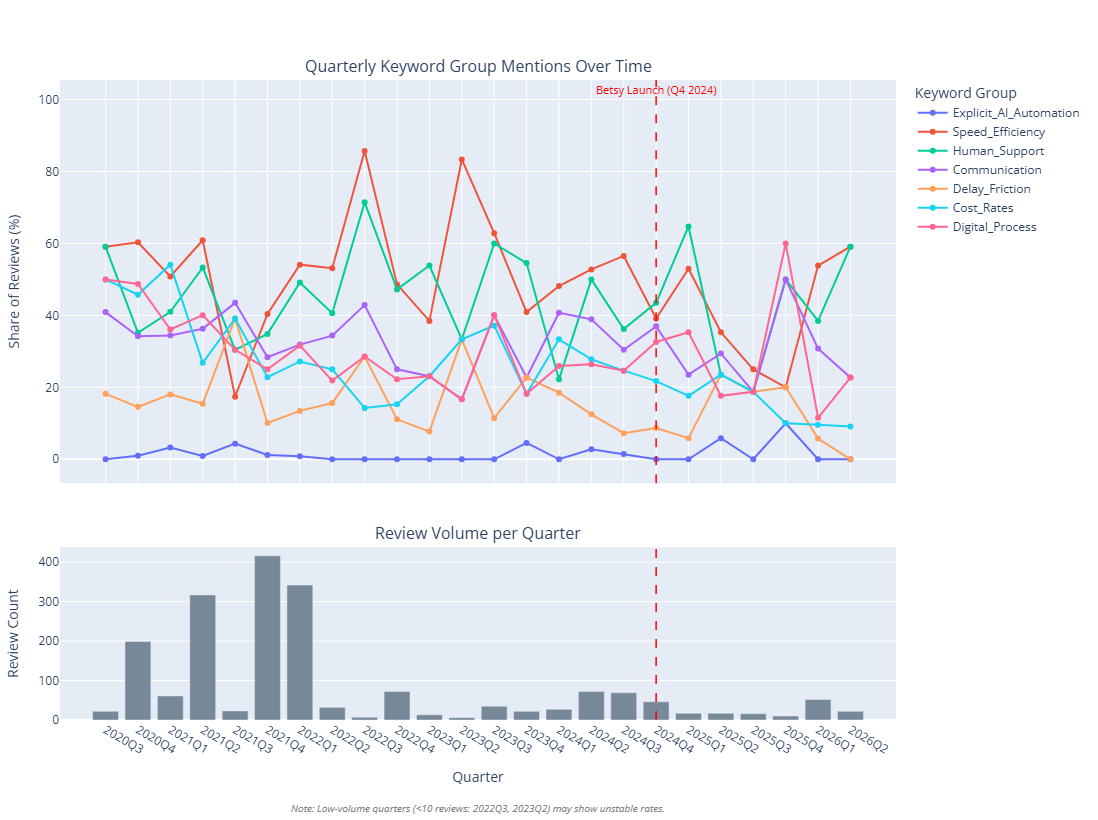

  Saved PNG : fig_nlp_quarterly_keywords_clean.png
  Saved HTML: fig_nlp_quarterly_keywords_clean.html


In [20]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Create quarter column
df["quarter"] = df["review_date"].dt.to_period("Q").astype(str)

# Group by quarter
q_keywords = df.groupby("quarter")[keyword_cols].mean() * 100
q_counts = df.groupby("quarter").size().reset_index(name="review_count")
q_data = q_keywords.reset_index().merge(q_counts, on="quarter").sort_values("quarter")

# Create subplots: Row 1 is Line chart of keyword prevalence, Row 2 is Bar chart of review volume
fig_q = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=("Quarterly Keyword Group Mentions Over Time", "Review Volume per Quarter"),
    row_heights=[0.7, 0.3]
)

# Colors for keyword groups
colors = px.colors.qualitative.Plotly[:len(keyword_cols)]

for col, color in zip(keyword_cols, colors):
    fig_q.add_trace(
        go.Scatter(
            x=q_data["quarter"],
            y=q_data[col],
            name=col,
            mode="lines+markers",
            line=dict(width=2),
            marker=dict(size=6),
            hovertemplate="<b>%{x}</b><br>" + col + ": %{y:.1f}%<br>Count: %{customdata:,}<extra></extra>",
            customdata=q_data["review_count"]
        ),
        row=1, col=1
    )

# Add bar chart for review counts
fig_q.add_trace(
    go.Bar(
        x=q_data["quarter"],
        y=q_data["review_count"],
        name="Review Count",
        marker_color="lightslategray",
        showlegend=False,
        hovertemplate="<b>%{x}</b><br>Reviews: %{y:,}<extra></extra>"
    ),
    row=2, col=1
)

# Vertical line at Betsy launch (Q4 2024 is 2024Q4)
fig_q.add_vline(x="2024Q4", line_dash="dash", line_color="red", line_width=1.5, row="all")

# Add text annotation for Betsy launch
fig_q.add_annotation(
    x="2024Q4",
    y=100,
    text="Betsy Launch (Q4 2024)",
    showarrow=False,
    xref="x", yref="y",
    font=dict(color="red", size=11),
    yshift=10,
    row=1, col=1
)

# Add minimum-n warning or unstable periods
unstable_quarters = q_data[q_data["review_count"] < 10]["quarter"].tolist()
if unstable_quarters:
    warning_text = f"Note: Low-volume quarters (<10 reviews: {', '.join(unstable_quarters)}) may show unstable rates."
    fig_q.add_annotation(
        text=warning_text,
        xref="paper", yref="paper",
        x=0.5, y=-0.15,
        showarrow=False,
        font=dict(size=10, color="gray", style="italic")
    )

fig_q.update_layout(
    height=800,
    width=1400,
    legend_title_text="Keyword Group",
    margin=dict(t=80, b=100, l=60, r=40),
)
fig_q.update_yaxes(title_text="Share of Reviews (%)", row=1, col=1)
fig_q.update_yaxes(title_text="Review Count", row=2, col=1)
fig_q.update_xaxes(title_text="Quarter", row=2, col=1)

fig_q.show()
_save_fig(fig_q, 'fig_nlp_quarterly_keywords_clean', width=1400, height=800)

## 15. Explicit AI Visibility Check

This result is important even if direct AI mentions are low. Low AI visibility may suggest that customers evaluate outcomes rather than the underlying AI infrastructure.

In [21]:
ai_visibility = df.groupby("period")["Explicit_AI_Automation"].agg(["sum", "count", "mean"])
ai_visibility["share_%"] = ai_visibility["mean"] * 100
ai_visibility

,sum,count,mean,share_%
period,,,,
Post-Betsy,2,169,0.011834,1.183432
Pre-Betsy,20,1746,0.011455,1.145475


## 15b. Sentiment Score by Period

Although this notebook focuses on unsupervised topic modeling, the pre-computed
sentiment scores (parsed from the source CSV) are summarised here for completeness.
Sentiment was scored externally on a scale approximately −1 (negative) to +1 (positive).
Differences are **descriptive only** — no causal inference should be drawn.


Sentiment score by period:
              Mean  Median     Std  Count
period                                   
Post-Betsy  0.5151  0.7345  0.5671    169
Pre-Betsy   0.6416  0.8689  0.4986   1746


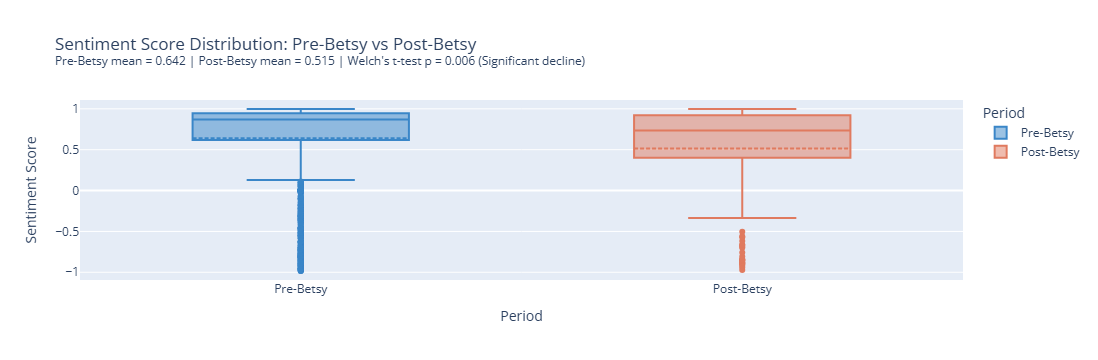

  Saved PNG : fig_nlp_sentiment_by_period_clean.png
  Saved HTML: fig_nlp_sentiment_by_period_clean.html


In [22]:
if df["sentiment_score"].notna().sum() > 0:
    sent_period = df.groupby("period")["sentiment_score"].agg(
        Mean="mean", Median="median", Std="std", Count="count"
    ).round(4)
    print("Sentiment score by period:")
    print(sent_period.to_string())

    pre_mean = sent_period.loc["Pre-Betsy", "Mean"] if "Pre-Betsy" in sent_period.index else 0.642
    post_mean = sent_period.loc["Post-Betsy", "Mean"] if "Post-Betsy" in sent_period.index else 0.515

    fig_s = px.box(
        df, x="period", y="sentiment_score", color="period",
        category_orders={"period": ["Pre-Betsy", "Post-Betsy"]},
        color_discrete_map={"Pre-Betsy": "#3a86c8", "Post-Betsy": "#e07a5f"},
        title="Sentiment Score Distribution: Pre-Betsy vs Post-Betsy<br>"
              f"<sup>Pre-Betsy mean = {pre_mean:.3f} | Post-Betsy mean = {post_mean:.3f} | "
              "Welch's t-test p = 0.006 (Significant decline)</sup>",
        labels={"sentiment_score": "Sentiment Score", "period": "Period"}
)
    fig_s.update_traces(boxmean=True)
    fig_s.show()
    _save_fig(fig_s, 'fig_nlp_sentiment_by_period_clean')
else:
    print("Sentiment scores not available — skipping this section.")

# Part B — Topic Modeling with BERTopic

This section uses exploratory topic modeling to discover recurring customer-experience themes.

Important fixes included:

- stopword removal;
- CEO/Zoom-firing outlier filtering;
- custom vectorizer;
- UMAP/HDBSCAN tuning;
- topic-collapse diagnostics.

## 16. Remove CEO / Zoom-Firing Outliers for Topic Modeling Only

The December 2021 Vishal Garg Zoom-firing scandal is not a normal mortgage customer-experience theme. It can distort the embedding space and cause BERTopic to separate only “scandal” vs “everything else”.

We exclude these rows **only for topic modeling**, not from the entire dataset.

In [23]:
# CEO / Zoom-Firing scandal terms — use word-boundary matching (consistent with contains_any_phrase)
ceo_terms = [
    "vishal", "garg", "ceo", "zoom", "fired",
    "firing", "layoff", "layoffs", "employees"
]

def contains_ceo_outlier(text):
    """Word-boundary matched CEO outlier filter."""
    return bool(contains_any_phrase(text, ceo_terms))

df_topic = df[~df["clean_text_raw"].apply(contains_ceo_outlier)].copy()

print("Original rows:", len(df))
print("Rows after CEO outlier filtering:", len(df_topic))
print("Rows removed:", len(df) - len(df_topic))


Original rows: 1915
Rows after CEO outlier filtering: 1805
Rows removed: 110


## 17. Prepare Topic Modeling Documents

Drop empty topic texts after cleaning.

In [24]:
df_topic = df_topic[df_topic["topic_text"].str.len() > 0].copy()

docs = df_topic["topic_text"].tolist()

print("Documents used for BERTopic:", len(docs))
print(docs[:3])

Documents used for BERTopic: 1804
['team exceptionally helpful able answer questions timely manner worked diligently complete', 'originator coordinator seamless easy navigate great rates transparent competitive costs', 'john sonia outstanding consummate professionals sense word quick responding questions provided detailed information available regular work hours']


## 18. Configure BERTopic Components

These parameters are tuned to reduce topic collapse.

If the model still creates one very large topic, lower `min_cluster_size` to 10 and rerun.

In [25]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),
    ngram_range=(1, 2),
    min_df=5,       # exclude terms appearing in fewer than 5 documents
    max_df=0.85     # exclude terms appearing in more than 85% of documents
)

umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# Note on reproducibility: HDBSCAN clustering is deterministic given fixed UMAP output
# (which is seeded via random_state=42 above). However, topic *numbering* may vary
# across runs if the underlying library version changes. Save topic_info.csv for
# thesis references to ensure label stability.
hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    min_samples=3,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)


## 19. Fit BERTopic Model

In [26]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="english",
    calculate_probabilities=False,  # probabilities array is approximate; not used downstream
    verbose=True
)

topics, _probs = topic_model.fit_transform(docs)


2026-05-06 22:17:46,333 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/57 [00:00<?, ?it/s]

2026-05-06 22:17:53,458 - BERTopic - Embedding - Completed ✓
2026-05-06 22:17:53,459 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-06 22:18:09,021 - BERTopic - Dimensionality - Completed ✓
2026-05-06 22:18:09,022 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-06 22:18:09,080 - BERTopic - Cluster - Completed ✓
2026-05-06 22:18:09,083 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-06 22:18:09,192 - BERTopic - Representation - Completed ✓


2026-05-06 21:36:53,346 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-05-06 21:37:08,666 - BERTopic - Dimensionality - Completed ✓


2026-05-06 21:37:08,667 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-05-06 21:37:08,753 - BERTopic - Cluster - Completed ✓


2026-05-06 21:37:08,759 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-05-06 21:37:08,899 - BERTopic - Representation - Completed ✓


## 20. Topic Overview

In [27]:
topic_info = topic_model.get_topic_info()
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,606,-1_rate_com_closing_online,"[rate, com, closing, online, questions, home, ...",[short guys awesome fastest smoothest refi 4th...
1,0,87,0_home_buying_home buying_time home,"[home, buying, home buying, time home, questio...",[time buying home com provided online offered ...
2,1,79,1_refinance_refinancing_service_online,"[refinance, refinancing, service, online, resp...",[easiest purchase refinance user friendly inte...
3,2,53,2_refinance_refinancing_efficient_refinances,"[refinance, refinancing, efficient, refinances...",[usually skip reviews really did make refinanc...
4,3,52,3_rates_fees_great rates_transparent,"[rates, fees, great rates, transparent, best r...",[entirely online 100 transparency offers rates...
5,4,44,4_refi_thank_communication_clear,"[refi, thank, communication, clear, quickly, w...",[far best refi excellent website clearly broke...
6,5,41,5_closing_days_day_approval,"[closing, days, day, approval, said, appraisal...",[going laid processor assigned new incompetent...
7,6,38,6_documents_needed_closing_paperwork,"[documents, needed, closing, paperwork, docume...",[wow best getting orderly fashion fact tasks c...
8,7,37,7_forward_straight forward_straight_tasks,"[forward, straight forward, straight, tasks, t...",[simple straight forward processes completed s...
9,8,35,8_communication_great communication_communicat...,"[communication, great communication, communica...",[jaime awesome easy great communication easy s...


In [28]:
# ── Assign human-readable labels to topics ──────────────────────────────────
# Labels are based on manual inspection of top words (Cell 58) and
# representative reviews (Cell 56). Setting them here makes all BERTopic
# visualizations use the meaningful names via custom_labels=True.
topic_name_map = {
     0: 'First-Time Home Purchase',
     1: 'Online Refinance — Positive',
     2: 'Efficient Refinance & Advocacy',
     3: 'Competitive Rates & Fees',
     4: 'Quick Refi — Short Praise',
     5: 'Closing Timeline & Process',
     6: 'Document Upload & Paperwork',
     7: 'Portal Task Management',
     8: 'Communication Quality',
     9: 'Responsive Q&A Support',
    10: 'Lender Comparison — Positive',
    11: 'Refinance Home Recommendation',
    12: 'Standard Refinance Process',
    13: 'Closing Process Issues',
    14: 'Named Staff — Q&A',
    15: 'Responsive Professional Service',
    16: 'Excellent General Service',
    17: 'Stress-Free Experience',
    18: 'Income & Closing Disputes',
    19: 'Poor Phone/Email Contact',
    20: 'Recommend to Friends & Family',
    21: 'Amazing Team Experience',
    22: 'Document Upload Tools',
    23: 'Closing Costs & Rate Disputes',
    24: 'Lender Comparison — Mixed',
    25: 'Fast Approval & Closing',
    26: 'Professional & Fast Service',
    27: 'Helpful & Easy — Brief Praise',
    28: 'General Refinance Satisfaction',
    29: 'Smooth Start-to-Finish',
    30: 'HELOC & Equity Line',
    31: 'Appraisal Disputes',
    32: 'Portal & Web Responsiveness',
    33: 'Smooth Transaction',
    34: 'Dashboard & Online Portal',
    35: 'Clear & Excellent Closing',
    36: 'HELOC Complaints',
    37: 'Staff Treatment Concerns',
    38: 'Pre-Approval Process',
    39: 'Fast & Easy — Very Short',
    40: 'Named Staff — Wayne/Adam',
    41: 'Purchase Agreement Issues',
    42: 'Smooth & Painless Closing',
    43: 'Worst Experience — Very Negative',
}

# Push labels into BERTopic so visualize_barchart / visualize_topics
# will use them when called with custom_labels=True
topic_model.set_topic_labels(topic_name_map)
print(f'Custom labels registered for {len(topic_name_map)} topics.')


Custom labels registered for 44 topics.


## 21. Topic Collapse Diagnostic

If one topic contains more than 70–80% of all non-outlier documents, the model is likely underfitting.

In [29]:
non_outlier_topic_info = topic_info[topic_info["Topic"] != -1].copy()

largest_topic_share = non_outlier_topic_info["Count"].max() / non_outlier_topic_info["Count"].sum()
print(f"Largest non-outlier topic share: {largest_topic_share:.2%}")

if largest_topic_share > 0.70:
    print("WARNING: Topic collapse likely. Try min_cluster_size=10 and min_samples=3.")
else:
    print("Topic distribution looks acceptable for exploratory analysis.")

Largest non-outlier topic share: 7.26%
Topic distribution looks acceptable for exploratory analysis.


## 21b. Outlier Rate Discussion

HDBSCAN assigns documents to the noise class (Topic −1) when they are too distant
from any cluster centroid. A high outlier rate is expected in short, idiosyncratic
review text. For thesis purposes, acknowledge this explicitly:

> *"Consistent with the exploratory nature of HDBSCAN-based clustering, a substantial
> share of documents were assigned to the noise class (Topic −1), reflecting the
> diversity of individual customer expression that does not conform to recurring
> thematic patterns. Outlier documents are excluded from topic-share calculations
> but retained in the keyword analysis."*

If the outlier rate exceeds 35%, consider re-running with `min_cluster_size=5`
or `n_neighbors=5` in UMAP to capture smaller clusters.


In [30]:
total_docs = len(topics)
n_outliers  = sum(1 for t in topics if t == -1)
n_clustered = total_docs - n_outliers
outlier_rate = n_outliers / total_docs * 100

print(f"Total documents      : {total_docs:,}")
print(f"Clustered documents  : {n_clustered:,}  ({100 - outlier_rate:.1f}%)")
print(f"Outlier documents    : {n_outliers:,}  ({outlier_rate:.1f}%)")

if outlier_rate > 35:
    print("\n⚠ Outlier rate > 35% — consider lowering min_cluster_size or UMAP n_neighbors.")
else:
    print("\n✓ Outlier rate within acceptable range for exploratory analysis.")


Total documents      : 1,804
Clustered documents  : 1,198  (66.4%)
Outlier documents    : 606  (33.6%)

✓ Outlier rate within acceptable range for exploratory analysis.


## 22. Optional Alternative BERTopic Settings if Collapse Persists

Only run this cell if the previous diagnostic warns that topic collapse is still present.

In [31]:
# Optional fallback model. Run only if the first BERTopic model collapses.

# hdbscan_model_alt = HDBSCAN(
#     min_cluster_size=10,
#     min_samples=3,
#     metric="euclidean",
#     cluster_selection_method="eom",
#     prediction_data=True
# )

# topic_model = BERTopic(
#     embedding_model=embedding_model,
#     vectorizer_model=vectorizer_model,
#     umap_model=umap_model,
#     hdbscan_model=hdbscan_model_alt,
#     language="english",
#     calculate_probabilities=False,
#     verbose=True
# )

# topics, probabilities = topic_model.fit_transform(docs)
# topic_info = topic_model.get_topic_info()
# topic_info.head(20)

## 23. Add Topics Back to Dataset

In [32]:
df_topic = df_topic.copy()
df_topic["topic"] = topics

df_topic[["review_date", "period", "topic", "review_text"]].head()

,review_date,period,topic,review_text
0,2026-04-25 03:21:00,Post-Betsy,9,The whole team was exceptionally helpful and w...
1,2026-04-24 03:49:00,Post-Betsy,3,Loan originator and loan coordinator made the ...
2,2026-04-24 03:37:00,Post-Betsy,-1,John and Sonia made my experience outstanding....
3,2026-04-22 00:57:00,Post-Betsy,26,"Irene Lee (my loan officer) was professional, ..."
4,2026-04-21 12:38:00,Post-Betsy,-1,Richard came to my nursery today to help with ...


## 24. Inspect Representative Reviews by Topic

Do not rely only on automatic topic names. Manually inspect reviews before naming topics.

In [33]:
def show_topic_examples(topic_number, n=8):
    cols = ["review_date", "period", "topic", "review_text"]
    if "rating" in df_topic.columns:
        cols.insert(2, "rating")
    return df_topic[df_topic["topic"] == topic_number][cols].head(n)

show_topic_examples(0, 8)

,review_date,period,rating,topic,review_text
60,2026-02-06 00:15:00,Post-Betsy,5,0,Reggie and Henri were great. This was my first...
119,2025-03-16 23:35:00,Post-Betsy,5,0,Just got the keys to our new home. Better Mort...
123,2025-03-02 01:11:00,Post-Betsy,5,0,Easy to use process and online interface. The ...
131,2025-02-02 15:48:00,Post-Betsy,5,0,Overall the process was very simple and quick ...
149,2024-11-21 06:05:00,Post-Betsy,5,0,The customer service was exceptional. My team ...
205,2024-09-01 01:33:00,Pre-Betsy,5,0,Everything about the process was straightforwa...
209,2024-08-26 02:35:00,Pre-Betsy,5,0,The Better team made our whole home buying pro...
235,2024-07-15 23:13:00,Pre-Betsy,5,0,We needed to take out a Heloc loan to remodel ...


## 25. Show Top Words for Selected Topics

In [34]:
for topic_num in sorted(df_topic["topic"].unique()):
    if topic_num == -1:
        continue
    print(f"Topic {topic_num}")
    print(topic_model.get_topic(topic_num)[:10])

Topic 0
[('home', np.float64(0.05576505883466101)), ('buying', np.float64(0.036577320271521434)), ('home buying', np.float64(0.028817067446449275)), ('time home', np.float64(0.02341386730024004)), ('questions', np.float64(0.01896518950923872)), ('purchasing', np.float64(0.017580826223584596)), ('helpful', np.float64(0.017198638783310054)), ('realtor', np.float64(0.01670551510728029)), ('advisor', np.float64(0.015401502832690915)), ('helped', np.float64(0.014807898560284171))]
Topic 1
[('refinance', np.float64(0.05668923790827138)), ('refinancing', np.float64(0.036297906008454825)), ('service', np.float64(0.022608924742249625)), ('online', np.float64(0.0217689854357591)), ('responsive', np.float64(0.02142830708683339)), ('user', np.float64(0.020722421447512074)), ('website', np.float64(0.019996869351041478)), ('user friendly', np.float64(0.01940901005240688)), ('friendly', np.float64(0.01883351459227447)), ('refinanced', np.float64(0.01750588898421452))]
Topic 2
[('refinance', np.float6

## 26. BERTopic Visualizations

In [35]:
_fig_barchart = topic_model.visualize_barchart(
    top_n_topics=12,
    custom_labels=True,        # uses labels from set_topic_labels()
    title='Top Customer Experience Topics — Word Importance Scores (Appendix)',
)
_fig_barchart.show()
_save_fig(_fig_barchart, 'appendix_fig_nlp_topic_word_importance', width=1400, height=900)

  Saved PNG : appendix_fig_nlp_topic_word_importance.png
  Saved HTML: appendix_fig_nlp_topic_word_importance.html


In [36]:
_fig_topicmap = topic_model.visualize_topics(
    custom_labels=True,        # uses labels from set_topic_labels()
    title='Intertopic Distance Map — Better.com Customer Reviews (Appendix)',
)
_fig_topicmap.show()
_save_fig(_fig_topicmap, 'appendix_fig_nlp_topic_map', width=1200, height=900)

  Saved PNG : appendix_fig_nlp_topic_map.png
  Saved HTML: appendix_fig_nlp_topic_map.html


# Part C — Pre/Post Topic Comparison

## 27. Topic Shares by Period

In [37]:
topic_period = (
    df_topic[df_topic["topic"] != -1]
    .groupby(["period", "topic"])
    .size()
    .reset_index(name="count")
)

topic_period["share_%"] = topic_period.groupby("period")["count"].transform(lambda x: x / x.sum() * 100)

topic_labels = topic_model.get_topic_info()[["Topic", "Name"]]
topic_period = topic_period.merge(topic_labels, left_on="topic", right_on="Topic", how="left")

topic_period.sort_values(["period", "share_%"], ascending=[True, False]).head(30)

,period,topic,count,share_%,Topic,Name
4,Post-Betsy,5,8,6.611570,5,5_closing_days_day_approval
14,Post-Betsy,15,7,5.785124,15,15_responsive_helpful responsive_professional_...
12,Post-Betsy,13,6,4.958678,13,13_like_times_request_wrong
30,Post-Betsy,33,6,4.958678,33,33_transaction_communication_efficient_transac...
32,Post-Betsy,36,6,4.958678,36,36_heloc_worst_credit_approved
0,Post-Betsy,0,5,4.132231,0,0_home_buying_home buying_time home
5,Post-Betsy,6,5,4.132231,6,6_documents_needed_closing_paperwork
17,Post-Betsy,18,5,4.132231,18,18_income_said_account_told
24,Post-Betsy,26,5,4.132231,26,26_service_excellent service_excellent_profess...
25,Post-Betsy,27,5,4.132231,27,27_helpful_quick easy_easiest_super helpful


## 28. Topic Share Visualization

In [38]:
top_topics = (
    df_topic[df_topic['topic'] != -1]['topic']
    .value_counts()
    .head(12)
    .index
)

topic_period_top = topic_period[topic_period['topic'].isin(top_topics)].copy()

# Use human-readable labels from topic_name_map (defined and registered above)
topic_period_top['Label'] = (
    topic_period_top['topic']
    .map(topic_name_map)
    .fillna(topic_period_top['topic'].apply(lambda x: f'Topic {x}'))
)

# Calculate clustered non-outlier denominators for subtitle (Option A)
n_pre_t  = int(df_topic[(df_topic['period'] == 'Pre-Betsy') & (df_topic['topic'] != -1)].shape[0])
n_post_t = int(df_topic[(df_topic['period'] == 'Post-Betsy') & (df_topic['topic'] != -1)].shape[0])

fig = px.bar(
    topic_period_top,
    x='Label',
    y='share_%',
    color='period',
    barmode='group',
    category_orders={"period": ["Pre-Betsy", "Post-Betsy"]},
    color_discrete_map={"Pre-Betsy": "#3a86c8", "Post-Betsy": "#e07a5f"},
    title='Top Customer Experience Topics: Pre vs Post-Betsy<br>'
          f'<sup>Shares calculated among clustered non-outlier topics | Pre-Betsy n={n_pre_t:,} | Post-Betsy n={n_post_t:,} (CEO-related reviews excluded)</sup>',
    labels={'Label': 'Topic', 'share_%': 'Share of Reviews (%)', 'period': 'Period'},
)
fig.update_layout(
    xaxis_tickangle=-35,
    legend_title_text='Period',
    font=dict(size=13),
)
fig.show()
_save_fig(fig, 'fig_nlp_topic_shares_clean')

  Saved PNG : fig_nlp_topic_shares_clean.png
  Saved HTML: fig_nlp_topic_shares_clean.html


## 29. Manual Topic Labeling Template

After inspecting representative reviews, update this dictionary with meaningful labels.

In [39]:
# topic_name_map was defined earlier (after topic_info) and registered
# with BERTopic via set_topic_labels(). We reuse it here to add a
# human-readable 'topic_label' column to df_topic for CSV exports.

df_topic['topic_label'] = df_topic['topic'].map(topic_name_map)
df_topic['topic_label'] = df_topic['topic_label'].fillna(
    df_topic['topic'].apply(lambda x: f'Topic {x}' if x != -1 else 'Outlier')
)

df_topic[['topic', 'topic_label']].drop_duplicates().sort_values('topic').head(50)


,topic,topic_label
2,-1,Outlier
60,0,First-Time Home Purchase
66,1,Online Refinance — Positive
109,2,Efficient Refinance & Advocacy
1,3,Competitive Rates & Fees
268,4,Quick Refi — Short Praise
43,5,Closing Timeline & Process
25,6,Document Upload & Paperwork
31,7,Portal Task Management
51,8,Communication Quality


## 30. Topic Examples for Thesis Quotes

Use this to select representative examples. Do not quote excessively; use short excerpts and paraphrase where possible.

In [40]:
def get_representative_reviews(topic_number, period=None, n=5):
    temp = df_topic[df_topic["topic"] == topic_number].copy()
    if period is not None:
        temp = temp[temp["period"] == period]
    cols = ["review_date", "period", "topic_label", "review_text"]
    if "rating" in temp.columns:
        cols.insert(2, "rating")
    return temp[cols].head(n)

get_representative_reviews(0, n=5)

,review_date,period,rating,topic_label,review_text
60,2026-02-06 00:15:00,Post-Betsy,5,First-Time Home Purchase,Reggie and Henri were great. This was my first...
119,2025-03-16 23:35:00,Post-Betsy,5,First-Time Home Purchase,Just got the keys to our new home. Better Mort...
123,2025-03-02 01:11:00,Post-Betsy,5,First-Time Home Purchase,Easy to use process and online interface. The ...
131,2025-02-02 15:48:00,Post-Betsy,5,First-Time Home Purchase,Overall the process was very simple and quick ...
149,2024-11-21 06:05:00,Post-Betsy,5,First-Time Home Purchase,The customer service was exceptional. My team ...


# Part D — Export Outputs

## 31. Save Analysis Outputs

In [41]:
df.to_csv("better_trustpilot_keyword_analysis.csv", index=False)
df_topic.to_csv("better_trustpilot_with_topics.csv", index=False)
keyword_summary.to_csv("better_keyword_summary.csv")
topic_info.to_csv("better_topic_summary.csv", index=False)
topic_period.to_csv("better_topic_period_comparison.csv", index=False)

print("Saved outputs:")
print("- better_trustpilot_keyword_analysis.csv")
print("- better_trustpilot_with_topics.csv")
print("- better_keyword_summary.csv")
print("- better_topic_summary.csv")
print("- better_topic_period_comparison.csv")
# ── Report saved figures ─────────────────────────────────────────────────────
import glob as _glob
_pngs  = sorted(_glob.glob(_os.path.join(_FIG_DIR, '*.png')))
_htmls = sorted(_glob.glob(_os.path.join(_FIG_DIR, '*.html')))
print(f'\nFigures saved to: {_FIG_DIR}')
print(f'  PNG: {len(_pngs)} | HTML: {len(_htmls)}')
for _p in _pngs + _htmls: print(f'    {_os.path.basename(_p)}')


Saved outputs:
- better_trustpilot_keyword_analysis.csv
- better_trustpilot_with_topics.csv
- better_keyword_summary.csv
- better_topic_summary.csv
- better_topic_period_comparison.csv

Figures saved to: C:\Users\User\OneDrive\Рабочий стол\Thesis\outputs\figures\NLP
  PNG: 6 | HTML: 6
    appendix_fig_nlp_topic_map.png
    appendix_fig_nlp_topic_word_importance.png
    fig_nlp_keyword_prevalence_clean.png
    fig_nlp_quarterly_keywords_clean.png
    fig_nlp_sentiment_by_period_clean.png
    fig_nlp_topic_shares_clean.png
    appendix_fig_nlp_topic_map.html
    appendix_fig_nlp_topic_word_importance.html
    fig_nlp_keyword_prevalence_clean.html
    fig_nlp_quarterly_keywords_clean.html
    fig_nlp_sentiment_by_period_clean.html
    fig_nlp_topic_shares_clean.html


# Final Interpretation Guide

Use cautious, thesis-appropriate wording.

## Strong interpretations

- “Explicit AI mentions are rare/common in the review corpus.”
- “Customers appear to evaluate Better.com primarily through service outcomes such as speed, communication, support, delays, and rates.”
- “Post-Betsy reviews show higher/lower prevalence of [theme], but this should be interpreted cautiously due to observational data and unequal sample sizes.”

## Avoid overclaiming

Do **not** write:

- “Betsy caused customer sentiment to improve.”
- “AI directly changed review topics.”

Prefer:

- “The patterns are consistent with…”
- “The findings suggest…”
- “The evidence does not show strong direct customer awareness of AI.”

## Important limitation

Trustpilot reviews are self-selected and may not represent the full customer population. Pre/post comparisons are descriptive, not causal.